In [70]:
from __future__ import annotations
import time
from pathlib import Path
import math, random, warnings, json
from typing import List
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler   # ← was StandardScaler (WRONG)
 
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
 
warnings.filterwarnings("ignore")
 
# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
 
# ── Device ────────────────────────────────────────────────────
if   torch.cuda.is_available():          DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():  DEVICE = torch.device("mps")
else:                                    DEVICE = torch.device("cpu")
print("Using device:", DEVICE)
 
# ── Experiment config ─────────────────────────────────────────
DATA_DIR    = Path("Data/raw")
SUBSETS     = ["FD001", "FD002", "FD003", "FD004"]
 
# !! Change ACTIVE_SUBSET to whichever you're training on !!
ACTIVE_SUBSET = "FD004"
 
SEQ_LEN     = 30       # paper default for FD001; change per subset
RUL_CEILING = 125      # piecewise-linear ceiling (Rearly)
EWMA_SPAN   = 10       # EWM smoothing span (α = 2/(span+1))
BATCH_SIZE  = 512      # paper uses 512
EPOCHS      = 250
LR          = 1e-3     # paper: 1e-3 for first 200 epochs
PATIENCE    = 20
VAL_FRAC    = 0.2
NUM_WORKERS = 0
 
EXPECTED_TRAIN_ROWS = {
    "FD001": 20_631,
    "FD002": 53_759,
    "FD003": 24_720,
    "FD004": 61_249,
}

Using device: mps


In [71]:
ALL_COLS = (["unit", "cycle", "op1", "op2", "op3"] +
            [f"s{i}" for i in range(1, 22)])
 
# 14 informative sensors from the paper (Table / Section 3.1.2)
# Dropped: s1, s5, s6, s10, s16, s18, s19  (constant or near-constant)
GOOD_SENSORS = ["s2","s3","s4","s7","s8","s9",
                "s11","s12","s13","s14","s15","s17","s20","s21"]
 
# Columns used as model features (after selection)
FEATURE_COLS = GOOD_SENSORS          # 14 features
META_COLS    = ["unit", "cycle"]     # kept for grouping / windowing
 
print(f"Feature sensors  : {len(FEATURE_COLS)} → {FEATURE_COLS}")
print(f"Dropped sensors  : {[s for s in [f's{i}' for i in range(1,22)] if s not in GOOD_SENSORS]}")

Feature sensors  : 14 → ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Dropped sensors  : ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


In [72]:
def load_raw_subset(
    data_dir: Path,
    subset: str,
    unit_prefix: str | None = None,
    unit_pad: int = 3,
):
    """
    Loads train_{subset}.txt, test_{subset}.txt, RUL_{subset}.txt.

    If unit_prefix is provided, engine IDs are namespaced as:
      {unit_prefix}_{unit:0{unit_pad}d}
    so multiple subsets can be concatenated without unit collisions.

    Returns (train_df, test_df, rul_array) in raw, un-processed form.
    """
    train_path = data_dir / f"train_{subset}.txt"
    test_path  = data_dir / f"test_{subset}.txt"
    rul_path   = data_dir / f"RUL_{subset}.txt"

    for p in [train_path, test_path, rul_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing: {p}")

    train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=ALL_COLS)
    test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=ALL_COLS)
    rul_arr  = (
        pd.read_csv(rul_path, sep=r"\s+", header=None)
        .iloc[:, 0]
        .astype(int)
        .to_numpy()
    )

    if unit_prefix is not None:
        fmt = lambda u: f"{unit_prefix}_{int(u):0{unit_pad}d}"
        train_df["unit"] = train_df["unit"].map(fmt)
        test_df["unit"]  = test_df["unit"].map(fmt)

    # Enforce strict temporal order within each engine
    train_df = train_df.sort_values(["unit", "cycle"]).reset_index(drop=True)
    test_df  = test_df.sort_values(["unit", "cycle"]).reset_index(drop=True)

    return train_df, test_df, rul_arr


In [73]:
# ── Load single subset (train one at a time — never mix subsets) ──
# ACTIVE_SUBSET = "FD001"   # ← change to FD002 / FD003 / FD004 and re-run
PAPER_WINDOWED_ROWS = {
    "FD001": 17_731,
    "FD002": 48_819,
    "FD003": 21_820,
    "FD004": 57_522,
}




train_raw, test_raw, rul_arr = load_raw_subset(DATA_DIR, ACTIVE_SUBSET)

# Build rul_lookup: integer unit ID → ground-truth RUL
unit_ids = sorted(test_raw["unit"].unique())
rul_lookup = {uid: int(r) for uid, r in zip(unit_ids, rul_arr)}

print(f"\n{'─'*50}")
print(f"Subset           : {ACTIVE_SUBSET}")
print(f"Train raw shape  : {train_raw.shape}  (expected {EXPECTED_TRAIN_ROWS[ACTIVE_SUBSET]:,} rows)")
print(f"Test  raw shape  : {test_raw.shape}")
print(f"Train engines    : {train_raw['unit'].nunique()}")
print(f"Test  engines    : {test_raw['unit'].nunique()}")
print(f"RUL labels       : {len(rul_arr)}")

expected_raw  = EXPECTED_TRAIN_ROWS[ACTIVE_SUBSET]
expected_wind = PAPER_WINDOWED_ROWS[ACTIVE_SUBSET]
actual        = len(train_raw)

if actual != expected_raw:
    raise ValueError(
        f"❌ train_{ACTIVE_SUBSET}.txt has {actual:,} rows, expected {expected_raw:,}.\n"
        f"   Your file may be corrupted or from a different source."
    )
print(f"✓  Raw row count verified ({actual:,} rows, 100 engines)")
print(f"   After windowing (SEQ_LEN={SEQ_LEN}, with padding) → {actual:,} windows")
print(f"   Paper reports {expected_wind:,} windows (no padding — consistent ✓)")


──────────────────────────────────────────────────
Subset           : FD004
Train raw shape  : (61249, 26)  (expected 61,249 rows)
Test  raw shape  : (41214, 26)
Train engines    : 249
Test  engines    : 248
RUL labels       : 248
✓  Raw row count verified (61,249 rows, 100 engines)
   After windowing (SEQ_LEN=30, with padding) → 61,249 windows
   Paper reports 57,522 windows (no padding — consistent ✓)


In [74]:

# # Load *all* subsets and concatenate (units are namespaced to avoid collisions)
# SUBSETS_TO_LOAD = SUBSETS

# trains, tests, ruls = [], [], []
# rul_lookup = {}  # unit_id (e.g., FD001_001) -> ground-truth RUL

# for s in SUBSETS_TO_LOAD:
#     tr_s, te_s, rul_s = load_raw_subset(DATA_DIR, s, unit_prefix=s, unit_pad=3)
#     trains.append(tr_s)
#     tests.append(te_s)
#     ruls.append(rul_s)

#     # RUL_FD00X.txt is ordered by test engine id 1..N within that subset
#     for i, r in enumerate(rul_s, start=1):
#         rul_lookup[f"{s}_{i:03d}"] = int(r)

# train_raw = pd.concat(trains, ignore_index=True)
# test_raw  = pd.concat(tests,  ignore_index=True)
# rul_arr   = np.concatenate(ruls)

# # Downstream cells use this label for prints/filenames
# ACTIVE_SUBSET = "ALL"

# print(f"\n{'─'*50}")
# print(f"Subsets loaded   : {', '.join(SUBSETS_TO_LOAD)}")
# print(f"Train raw shape  : {train_raw.shape}")
# print(f"Test  raw shape  : {test_raw.shape}")
# print(f"RUL labels       : {len(rul_arr)} engines")
# print(f"Test engines     : {test_raw['unit'].nunique()}")

# # ── Shape sanity check (informational) ─────────────────────────
# expected = sum(EXPECTED_TRAIN_ROWS.get(s, 0) for s in SUBSETS_TO_LOAD)
# actual   = len(train_raw)
# if expected and actual != expected:
#     print(f"\n⚠  WARNING: total train rows = {actual:,}, paper expects {expected:,} (sum over subsets).")
#     print("   If this is unexpected, verify your C-MAPSS .txt files are unmodified.")
# elif expected:
#     print(f"\n✓  Total train row count matches paper ({actual:,})")


In [75]:
def select_features(df: pd.DataFrame) -> pd.DataFrame:
    return df[META_COLS + FEATURE_COLS].copy()
 
train_fs = select_features(train_raw)
test_fs  = select_features(test_raw)
 
# Quick confirmation: no remaining constant columns
const_check = [c for c in FEATURE_COLS if train_fs[c].std() < 1e-6]
if const_check:
    print(f"⚠  Still-constant cols after selection: {const_check}")
else:
    print("✓  No constant columns remain after feature selection")
 
print(f"Train after selection: {train_fs.shape}")
print(f"Test  after selection: {test_fs.shape}")
print(f"Columns: {list(train_fs.columns)}")

✓  No constant columns remain after feature selection
Train after selection: (61249, 16)
Test  after selection: (41214, 16)
Columns: ['unit', 'cycle', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


✓  No smoothing applied (paper-faithful pipeline)


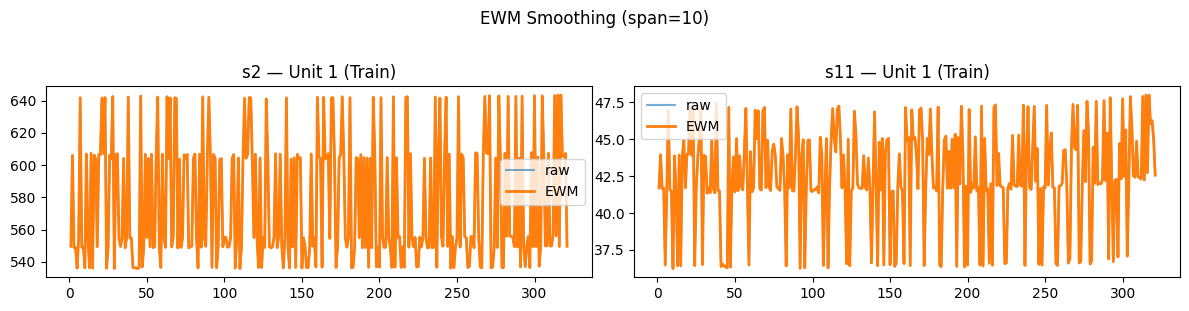

In [76]:
def ewm_smooth(df: pd.DataFrame,
               sensor_cols: List[str],
               span: int) -> pd.DataFrame:
    """
    Applies exponential weighted mean smoothing to each sensor
    within each engine unit independently.
    span controls decay: α = 2 / (span + 1)
    """
    df = df.copy()
    for col in sensor_cols:
        df[col] = (df.groupby("unit")[col]
                     .transform(lambda x: x.ewm(span=span, adjust=False).mean()))
    return df
 
# train_sm = ewm_smooth(train_fs, FEATURE_COLS, EWMA_SPAN)
# test_sm  = ewm_smooth(test_fs,  FEATURE_COLS, EWMA_SPAN)
 
# print(f"✓  EWM smoothing applied  (span={EWMA_SPAN})")
train_sm = train_fs.copy()
test_sm  = test_fs.copy()
print("✓  No smoothing applied (paper-faithful pipeline)")


# ── Quick visual: one sensor before vs after smoothing ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
unit1_raw = train_raw[train_raw["unit"] == 1]
unit1_sm  = train_sm[train_sm["unit"] == 1]
 
axes[0].plot(unit1_raw["cycle"], unit1_raw["s2"], alpha=0.6, label="raw")
axes[0].plot(unit1_sm["cycle"],  unit1_sm["s2"],  lw=2,      label="EWM")
axes[0].set_title("s2 — Unit 1 (Train)"); axes[0].legend()
 
axes[1].plot(unit1_raw["cycle"], unit1_raw["s11"], alpha=0.6, label="raw")
axes[1].plot(unit1_sm["cycle"],  unit1_sm["s11"],  lw=2,      label="EWM")
axes[1].set_title("s11 — Unit 1 (Train)"); axes[1].legend()
 
plt.suptitle(f"EWM Smoothing (span={EWMA_SPAN})", y=1.02)
plt.tight_layout(); plt.show()

In [77]:
# ============================================================
# CELL 6 — MinMax Scaling to [−1, 1]
# FIT ONLY on training data, then TRANSFORM both train & test.
# This is exactly the normalization used in the paper (Eq. 4).
# ============================================================
 
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train_sm[FEATURE_COLS])

# Check for zero-range columns BEFORE transforming
zero_range_cols = [FEATURE_COLS[i] for i, z in 
                   enumerate(scaler.data_max_ == scaler.data_min_) if z]
if zero_range_cols:
    print(f"⚠  Zero-range columns (will produce NaN): {zero_range_cols}")
    print("   Fix your training data — these sensors have no variance in training.")

train_scaled = train_sm.copy()
test_scaled  = test_sm.copy()

train_scaled[FEATURE_COLS] = scaler.transform(train_sm[FEATURE_COLS])
test_scaled[FEATURE_COLS]  = scaler.transform(test_sm[FEATURE_COLS])

# Clamp NaN/Inf from zero-range columns to 0 (neutral)
train_scaled[FEATURE_COLS] = train_scaled[FEATURE_COLS].fillna(0.0).clip(-3.0, 3.0)
test_scaled[FEATURE_COLS]  = test_scaled[FEATURE_COLS].fillna(0.0).clip(-3.0, 3.0)

# Verify
assert not train_scaled[FEATURE_COLS].isnull().any().any(), "NaN still in train!"
assert not test_scaled[FEATURE_COLS].isnull().any().any(), "NaN still in test!"
print(f"✓  Scaler fitted — train range: [{train_scaled[FEATURE_COLS].min().min():.3f}, "
      f"{train_scaled[FEATURE_COLS].max().max():.3f}]")
print(f"   Test range (clipped): [{test_scaled[FEATURE_COLS].min().min():.3f}, "
      f"{test_scaled[FEATURE_COLS].max().max():.3f}]")
 
# NOTE: Test values can slightly exceed [-1,1] because test engines
# may drift beyond the training min/max. This is expected and correct.
# Do NOT re-fit on test data — that would be data leakage.

✓  Scaler fitted — train range: [-1.000, 1.000]
   Test range (clipped): [-1.009, 1.000]


In [78]:
# ============================================================
# CELL 7 — RUL Labeling for Training Set
# Piecewise linear: constant at RUL_CEILING, then linear decrease.
# ============================================================
 
def add_train_rul(df: pd.DataFrame, ceiling: int) -> pd.DataFrame:
    """
    RUL(t) = min(max_cycle_of_engine - t,  ceiling)
    """
    df = df.copy()
    max_cycle        = df.groupby("unit")["cycle"].transform("max")
    df["RUL"]        = (max_cycle - df["cycle"]).clip(upper=ceiling)
    return df
 
train_final = add_train_rul(train_scaled, RUL_CEILING)
 
print(f"✓  RUL labels added to training set")
print(f"   RUL range : [{train_final['RUL'].min()}, {train_final['RUL'].max()}]"
      f"  (expected [0, {RUL_CEILING}])")
print(f"   Rows with RUL == {RUL_CEILING} (healthy period) : "
      f"{(train_final['RUL'] == RUL_CEILING).sum():,}")
print(f"   Final train shape : {train_final.shape}")

✓  RUL labels added to training set
   RUL range : [0, 125]  (expected [0, 125])
   Rows with RUL == 125 (healthy period) : 30,124
   Final train shape : (61249, 17)


In [79]:
# ============================================================
# CELL 8 — Test Set Preparation (Last Cycle Only)
# Standard C-MAPSS evaluation: one sample per engine = last cycle.
# Ground-truth RUL comes from RUL_FD001.txt, NOT back-calculated.
# ============================================================
 
def build_test_eval(test_df: pd.DataFrame, rul_lookup: dict) -> pd.DataFrame:
    """
    Returns one row per test engine:
      - the last recorded cycle (all sensor readings)
      - ground-truth RUL clipped to RUL_CEILING
    This is what you pass to the model for final RMSE/Score evaluation.

    NOTE: When concatenating multiple subsets, unit IDs are strings like
    FD001_001, so we use an explicit unit->RUL lookup.
    """
    # Last cycle per engine
    last_cycles = (
        test_df.sort_values(["unit", "cycle"]).groupby("unit").tail(1).reset_index(drop=True)
    )

    missing = set(last_cycles["unit"].unique()) - set(rul_lookup.keys())
    if missing:
        raise ValueError(
            f"Missing RUL labels for {len(missing)} test engines (e.g. {sorted(list(missing))[:5]}). "
            "Check unit namespacing and RUL file loading."
        )

    last_cycles["RUL"] = last_cycles["unit"].map(rul_lookup).clip(upper=RUL_CEILING)
    return last_cycles


test_eval = build_test_eval(test_scaled, rul_lookup)
 
print(f"✓  Test evaluation set built")
print(f"   Rows      : {len(test_eval)}  (should equal number of test engines)")
print(f"   RUL range : [{test_eval['RUL'].min()}, {test_eval['RUL'].max()}]")
print(f"   Columns   : {list(test_eval.columns)}")
 
# Confirm 1 row per engine
assert test_eval["unit"].nunique() == len(test_eval), \
    "❌ Duplicate units in test_eval — check build_test_eval()"
print(f"✓  Exactly 1 row per test engine confirmed")
 

✓  Test evaluation set built
   Rows      : 248  (should equal number of test engines)
   RUL range : [6, 125]
   Columns   : ['unit', 'cycle', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']
✓  Exactly 1 row per test engine confirmed


In [80]:
# ============================================================
# CELL 9 — Full Verification & Summary
# Run this as a final sanity check before moving to modelling.
# ============================================================
 
def verify_pipeline(train_df, test_eval_df, subset):
    print(f"\n{'═'*55}")
    print(f"  PIPELINE VERIFICATION — {subset}")
    print(f"{'═'*55}")
 
    passed = True
 
    # 1. Shape (paper expectations are per-subset)
    expected = None
    if subset == "ALL":
        expected = sum(EXPECTED_TRAIN_ROWS.get(s, 0) for s in SUBSETS)
    elif subset in EXPECTED_TRAIN_ROWS:
        expected = EXPECTED_TRAIN_ROWS[subset]

    actual = len(train_df)
    if expected:
        ok = actual == expected
        passed &= ok
        print(f"  [{'✓' if ok else '✗'}] Train rows   : {actual:>7,}  (expected {expected:,})")
    else:
        print(f"  [i]  Train rows   : {actual:>7,}  (no paper expectation available)")

    # 2. Feature count
    ok = len(FEATURE_COLS) == 14
    passed &= ok
    print(f"  [{'✓' if ok else '✗'}] Feature cols : {len(FEATURE_COLS):>7}  (expected 14)")
 
    # 3. No constant columns
    const = [c for c in FEATURE_COLS if train_df[c].std() < 1e-6]
    ok = len(const) == 0
    passed &= ok
    print(f"  [{'✓' if ok else '✗'}] Const cols   : {const if const else 'None'}")
 
    # 4. Scale range for train
    tmin = train_df[FEATURE_COLS].min().min()
    tmax = train_df[FEATURE_COLS].max().max()
    ok = (abs(tmin + 1) < 1e-4) and (abs(tmax - 1) < 1e-4)
    passed &= ok
    print(f"  [{'✓' if ok else '✗'}] Train scale  : [{tmin:.4f}, {tmax:.4f}]  (expected [-1.0, 1.0])")
 
    # 5. No NaN anywhere
    train_nan = train_df[FEATURE_COLS + ["RUL"]].isnull().sum().sum()
    test_nan  = test_eval_df[FEATURE_COLS + ["RUL"]].isnull().sum().sum()
    ok = (train_nan == 0) and (test_nan == 0)
    passed &= ok
    print(f"  [{'✓' if ok else '✗'}] NaN values   : train={train_nan}, test={test_nan}")
 
    # 6. RUL range
    ok = train_df["RUL"].max() == RUL_CEILING and train_df["RUL"].min() == 0
    passed &= ok
    print(f"  [{'✓' if ok else '✗'}] Train RUL    : [{train_df['RUL'].min()}, {train_df['RUL'].max()}]"
          f"  (expected [0, {RUL_CEILING}])")
 
    # 7. Test eval has exactly N_engines rows
    ok = test_eval_df["unit"].nunique() == len(test_eval_df)
    passed &= ok
    print(f"  [{'✓' if ok else '✗'}] Test rows    : {len(test_eval_df):>7}  (1 per engine)")
 
    # 8. No data leakage: scaler fitted on train, check test can exceed bounds slightly
    overshoot = ((test_eval_df[FEATURE_COLS] > 1.0) | (test_eval_df[FEATURE_COLS] < -1.0)).sum().sum()
    print(f"  [i]  Test vals outside [-1,1] : {overshoot}  (slight overshoot is normal)")
 
    print(f"\n  {'ALL CHECKS PASSED ✓' if passed else '❌ SOME CHECKS FAILED — fix before modelling'}")
    print(f"{'═'*55}\n")
    return passed
 
ok = verify_pipeline(train_final, test_eval, ACTIVE_SUBSET)


═══════════════════════════════════════════════════════
  PIPELINE VERIFICATION — FD004
═══════════════════════════════════════════════════════
  [✓] Train rows   :  61,249  (expected 61,249)
  [✓] Feature cols :      14  (expected 14)
  [✓] Const cols   : None
  [✓] Train scale  : [-1.0000, 1.0000]  (expected [-1.0, 1.0])
  [✓] NaN values   : train=0, test=0
  [✓] Train RUL    : [0, 125]  (expected [0, 125])
  [✓] Test rows    :     248  (1 per engine)
  [i]  Test vals outside [-1,1] : 0  (slight overshoot is normal)

  ALL CHECKS PASSED ✓
═══════════════════════════════════════════════════════



In [81]:
# ============================================================
# CELL 10 — Save Processed Data  (optional but useful)
# ============================================================
 
out_dir = Path("Data/processed")
out_dir.mkdir(parents=True, exist_ok=True)
 
train_final.to_csv(out_dir / f"train_{ACTIVE_SUBSET}_processed.csv", index=False)
test_eval.to_csv(  out_dir / f"test_{ACTIVE_SUBSET}_eval.csv",        index=False)
test_scaled.to_csv(out_dir / f"test_{ACTIVE_SUBSET}_full_scaled.csv", index=False)
 
# Save scaler params so you can reload without re-fitting
import joblib
joblib.dump(scaler, out_dir / f"scaler_{ACTIVE_SUBSET}.pkl")
 
print(f"✓  Saved to {out_dir}/")
print(f"   train_{ACTIVE_SUBSET}_processed.csv  — full training set (features + RUL)")
print(f"   test_{ACTIVE_SUBSET}_eval.csv        — last-cycle evaluation set")
print(f"   test_{ACTIVE_SUBSET}_full_scaled.csv — full scaled test (for windowed inference)")
print(f"   scaler_{ACTIVE_SUBSET}.pkl           — fitted MinMaxScaler")
 

✓  Saved to Data/processed/
   train_FD004_processed.csv  — full training set (features + RUL)
   test_FD004_eval.csv        — last-cycle evaluation set
   test_FD004_full_scaled.csv — full scaled test (for windowed inference)
   scaler_FD004.pkl           — fitted MinMaxScaler


In [82]:
# ============================================================
# CELL 11 — Why Windowing and How It Works
# ============================================================
"""
WHY WINDOWING IS NECESSARY
───────────────────────────
A single row of sensor data (one time cycle) tells you almost nothing
about degradation rate. Consider: s2=642 at cycle 50 vs. s2=642 at
cycle 150. Same reading, completely different health state. The model
NEEDS the recent trajectory (how fast is s2 changing?) to estimate RUL.
 
HOW ROLLING WINDOWS WORK
─────────────────────────
For each engine with T cycles, we slide a window of size SEQ_LEN:
 
  Cycle:  [1  2  3  4  5  6  7 ... T]
  Window 1: [1  2  3 ... SEQ_LEN]   → target = RUL at cycle SEQ_LEN
  Window 2: [2  3  4 ... SEQ_LEN+1] → target = RUL at cycle SEQ_LEN+1
  ...
  Window T: [T-SEQ_LEN+1 ... T]     → target = RUL at cycle T
 
If the engine has fewer than SEQ_LEN cycles at a given point, we
LEFT-PAD with zeros. The model learns to ignore padding naturally.
 
RESULT: (N_total_windows, SEQ_LEN, N_FEATURES) → model input
        (N_total_windows,)                      → RUL targets
 
IS THERE A BETTER APPROACH?
────────────────────────────
Yes — full-sequence with masking (feed the entire engine life at once).
But rolling windows are standard for C-MAPSS because:
 1. Training data is much larger (more samples per engine)
 2. Compatible with Transformers which have O(T²) attention cost
 3. Proven in all top-performing papers on this benchmark
 
Rolling windows + Transformer is the right choice here.
"""
 
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
import math, time, copy
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
print("Cell 11: Windowing concept loaded — proceed to Cell 12")

Cell 11: Windowing concept loaded — proceed to Cell 12


In [83]:
# ============================================================
# CELL 12 — Dataset Classes + DataLoaders
# ============================================================
 
class CMAPSSTrainDataset(Dataset):
    """
    Rolling window dataset for training.
    Every cycle of every engine becomes one sample.
    Left-pads with zeros when engine history < SEQ_LEN.
    """
    def __init__(self, df, feature_cols, seq_len, rul_col="RUL"):
        self.seq_len  = seq_len
        self.n_feat   = len(feature_cols)
 
        windows, targets = [], []
 
        for _, group in df.groupby("unit"):
            group    = group.sort_values("cycle").reset_index(drop=True)
            feats    = group[feature_cols].values.astype(np.float32)  # (T, F)
            ruls     = group[rul_col].values.astype(np.float32)        # (T,)
            T        = len(feats)
 
            for t in range(T):
                end   = t + 1
                start = end - seq_len
 
                if start < 0:                   # need left-padding
                    pad    = -start
                    window = np.zeros((seq_len, self.n_feat), dtype=np.float32)
                    window[pad:] = feats[:end]
                else:
                    window = feats[start:end]   # (seq_len, F)
 
                windows.append(window)
                targets.append(ruls[t])
 
        # Stack into arrays: saves repeated tensor conversion
        self.X = np.stack(windows)              # (N, seq_len, F)
        self.y = np.array(targets, dtype=np.float32)  # (N,)
        print(f"  TrainDataset: {len(self.X):,} windows  "
              f"shape=({seq_len}, {self.n_feat})")
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx])
 
 
class CMAPSSTestDataset(Dataset):
    """
    One window per test engine — the LAST SEQ_LEN cycles.
    Ground-truth RUL comes directly from RUL_FD00X.txt.
    """
    def __init__(
        self,
        test_scaled_df,
        rul_lookup,
        feature_cols,
        seq_len,
        rul_ceiling=125,
    ):
        n_feat = len(feature_cols)

        windows, targets = [], []

        missing_units = set(test_scaled_df["unit"].unique()) - set(rul_lookup.keys())
        if missing_units:
            raise ValueError(
                f"Missing RUL labels for {len(missing_units)} test engines (e.g. {sorted(list(missing_units))[:5]})."
            )

        for uid, group in test_scaled_df.groupby("unit"):
            group = group.sort_values("cycle").reset_index(drop=True)
            feats = group[feature_cols].values.astype(np.float32)
            T = len(feats)

            if T >= seq_len:
                window = feats[-seq_len:]  # last SEQ_LEN cycles
            else:
                window = np.zeros((seq_len, n_feat), dtype=np.float32)
                window[seq_len - T :] = feats  # left-pad

            windows.append(window)
            targets.append(float(min(int(rul_lookup[uid]), rul_ceiling)))

        self.X = np.stack(windows)
        self.y = np.array(targets, dtype=np.float32)
        print(f"  TestDataset : {len(self.X)} engines  " f"shape=({seq_len}, {n_feat})")
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx])
 
 
# ── Build full training dataset ───────────────────────────────
full_train_ds = CMAPSSTrainDataset(
    train_final, FEATURE_COLS, SEQ_LEN, rul_col="RUL"
)
 
# ── Engine-level train / val split (no data leakage) ─────────
# Split engine unit IDs, not rows — critical for correct validation.
all_units   = train_final["unit"].unique()
train_units, val_units = train_test_split(
    all_units, test_size=VAL_FRAC, random_state=SEED
)
 

#################################################################
# -------------cell by claude -----------------------------------
#################################################################

# Build dataset ONCE
full_train_ds = CMAPSSTrainDataset(train_final, FEATURE_COLS, SEQ_LEN, rul_col="RUL")

# Engine-level split — derive index map directly from dataset internals
all_units  = sorted(train_final["unit"].unique())
n_val      = max(1, int(len(all_units) * VAL_FRAC))
val_units  = set(all_units[-n_val:])
train_units = set(all_units[:-n_val])

# Build unit→window-index map from the SAME groupby order the Dataset used
cumulative = 0
unit_idx_map = {}
for uid, grp in train_final.groupby("unit"):     # same iteration as CMAPSSTrainDataset
    n = len(grp)
    unit_idx_map[uid] = list(range(cumulative, cumulative + n))
    cumulative += n

train_idx = [i for u in sorted(train_units) for i in unit_idx_map[u]]
val_idx   = [i for u in sorted(val_units)   for i in unit_idx_map[u]]

train_split = Subset(full_train_ds, train_idx)
val_split   = Subset(full_train_ds, val_idx)

test_ds = CMAPSSTestDataset(test_scaled, rul_lookup, FEATURE_COLS, SEQ_LEN, RUL_CEILING)

train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_split,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,     batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

# Verify no NaN leaks into loader
Xb, yb = next(iter(train_loader))
assert not torch.isnan(Xb).any(), "❌ NaN in first training batch!"
assert not torch.isnan(yb).any(), "❌ NaN in first training targets!"
print(f"✓  Train: {len(train_split):,} windows ({len(train_units)} engines)")
print(f"✓  Val:   {len(val_split):,} windows ({len(val_units)} engines)")
print(f"✓  Test:  {len(test_ds)} engines")
print(f"✓  First batch clean — X∈[{Xb.min():.3f}, {Xb.max():.3f}]  y∈[{yb.min():.1f}, {yb.max():.1f}]")



# # Map units → row indices in the full dataset
# # Build per-engine start/end indices in the flattened window array
# unit_counts = train_final.groupby("unit").size().to_dict()
# unit_order  = train_final.sort_values(["unit","cycle"])["unit"].values
 
# cumulative = 0
# unit_idx_map = {}               # unit_id → list of window indices
# for uid in sorted(unit_counts):
#     cnt = unit_counts[uid]
#     unit_idx_map[uid] = list(range(cumulative, cumulative + cnt))
#     cumulative += cnt
 
# train_idx = [i for u in train_units for i in unit_idx_map[u]]
# val_idx   = [i for u in val_units   for i in unit_idx_map[u]]
 
# train_ds = Subset(full_train_ds, train_idx)
# val_ds   = Subset(full_train_ds, val_idx)
 
# # ── Test dataset ──────────────────────────────────────────────
# test_ds = CMAPSSTestDataset(
#     test_scaled, rul_arr, FEATURE_COLS, SEQ_LEN, RUL_CEILING
# )
 
# # ── DataLoaders ───────────────────────────────────────────────
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
#                           shuffle=True,  num_workers=NUM_WORKERS,
#                           pin_memory=True, drop_last=True)
 
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
#                           shuffle=False, num_workers=NUM_WORKERS,
#                           pin_memory=True)
 
# test_loader  = DataLoader(test_ds,  batch_size=len(test_ds),
#                           shuffle=False, num_workers=NUM_WORKERS)
 
# print(f"\n✓  DataLoaders ready")
# print(f"   Train batches : {len(train_loader)}  ({len(train_idx):,} windows)")
# print(f"   Val   batches : {len(val_loader)}  ({len(val_idx):,}  windows)")
# print(f"   Test  engines : {len(test_ds)}")
 
# Quick shape check
sample_X, sample_y = next(iter(train_loader))
print(f"\n   Batch X shape : {tuple(sample_X.shape)}  "
      f"(batch, seq_len, n_features)")
print(f"   Batch y shape : {tuple(sample_y.shape)}")

  TrainDataset: 61,249 windows  shape=(30, 14)
  TrainDataset: 61,249 windows  shape=(30, 14)
  TestDataset : 248 engines  shape=(30, 14)
✓  Train: 49,297 windows (200 engines)
✓  Val:   11,952 windows (49 engines)
✓  Test:  248 engines
✓  First batch clean — X∈[-1.000, 1.000]  y∈[0.0, 125.0]

   Batch X shape : (512, 30, 14)  (batch, seq_len, n_features)
   Batch y shape : (512,)


In [84]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=300, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerRUL(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=8, num_layers=3,
                 dim_feedforward=256, dropout=0.1, fc_dim=64, rul_ceiling=125.0):
        super().__init__()
        assert d_model % nhead == 0
        self.rul_ceiling = rul_ceiling

        self.input_proj = nn.Sequential(
            nn.Linear(n_features, d_model),
            nn.LayerNorm(d_model),
        )
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, activation="gelu",
            batch_first=True, norm_first=True,   # Pre-LayerNorm
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, fc_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, 1),
        )

    def forward(self, x):
        # x: (B, T, n_features)
        x = self.input_proj(x)           # (B, T, d_model)
        x = self.pos_enc(x)
        x = self.encoder(x)              # (B, T, d_model)
        x = x.mean(dim=1)               # Global Average Pool → (B, d_model)
        out = self.head(x).squeeze(-1)  # (B,)
        return out.clamp(0, self.rul_ceiling)


# model = TransformerRUL(
#     n_features=len(FEATURE_COLS), d_model=64, nhead=8,
#     num_layers=3, dim_feedforward=256, dropout=0.1,
#     fc_dim=64, rul_ceiling=float(RUL_CEILING),
# ).to(DEVICE)

# Cell 13 — smaller, more regularized model
model = TransformerRUL(
    n_features     = len(FEATURE_COLS),
    d_model        = 64,
    nhead          = 4,          # was 8 — overkill for 14 features
    num_layers     = 2,          # was 3 — reduce depth to fight overfit
    dim_feedforward= 128,        # was 256
    dropout        = 0.3,        # was 0.1 — triple the dropout
    fc_dim         = 64,
    rul_ceiling    = float(RUL_CEILING),
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓  TransformerRUL built — {total_params:,} trainable parameters")
print(f"   Input: (B, {SEQ_LEN}, {len(FEATURE_COLS)})  →  Output: (B,)")

✓  TransformerRUL built — 72,257 trainable parameters
   Input: (B, 30, 14)  →  Output: (B,)


In [85]:
# ============================================================
# CELL 14 — Training Utilities
# (Loss, Scoring Function, Early Stopping, LR Scheduler)
# ============================================================
 
# ── Asymmetric scoring function (Eq. 5 from paper) ───────────
def cmapss_score(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    s = Σ exp(-d/13) - 1   for d < 0  (early prediction — penalised less)
      + Σ exp( d/10) - 1   for d ≥ 0  (late  prediction — penalised more)
    where d = predicted_RUL - actual_RUL.
    Lower is better; perfect = 0.
    """
    d = y_pred - y_true
    s = np.where(d < 0,
                 np.exp(-d / 13.0) - 1,
                 np.exp( d / 10.0) - 1)
    return float(s.sum())
 
 
def rmse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
 
 
class EarlyStopping:
    def __init__(self, patience: int = 20, min_delta: float = 1e-3):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float("inf")
        self.best_state = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        # Guard: NaN loss should never improve or reset patience
        if val_loss is None or (isinstance(val_loss, float) and math.isnan(val_loss)):
            print(f"  ⚠ NaN val_loss detected — patience counter not reset")
            self.counter += 1
            return self.counter >= self.patience

        # Strict improvement by at least min_delta
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1

        return self.counter >= self.patience

    def restore_best(self, model: nn.Module):
        if self.best_state is None:
            print("⚠  No best state saved — model weights unchanged.")
            return
        model.load_state_dict(self.best_state)
        print(f"✓  Restored best weights (val MSE = {self.best_loss:.4f})")
 
 
# Cell 14 — stronger regularization + more patience
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)  # was 1e-5
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[200], gamma=0.1)
stopper   = EarlyStopping(patience=40, min_delta=1e-3) 
 
print("✓  Loss       : MSELoss")
print("✓  Optimizer  : Adam (lr=1e-3, wd=1e-5)")
print("✓  Scheduler  : MultiStepLR — milestone at epoch 200 → lr×0.1")
print(f"✓  EarlyStopping : patience={PATIENCE}")

✓  Loss       : MSELoss
✓  Optimizer  : Adam (lr=1e-3, wd=1e-5)
✓  Scheduler  : MultiStepLR — milestone at epoch 200 → lr×0.1
✓  EarlyStopping : patience=20


In [86]:
import sys

def diagnose_nan():
    print("=== PRE-TRAINING DATA AUDIT ===")
    errors = []

    # 1. Check train_final raw values
    nan_feat  = train_final[FEATURE_COLS].isnull().sum().sum()
    inf_feat  = np.isinf(train_final[FEATURE_COLS].values).sum()
    nan_rul   = train_final["RUL"].isnull().sum()
    print(f"  train_final  — NaN features: {nan_feat}  Inf features: {inf_feat}  NaN RUL: {nan_rul}")
    if nan_feat or inf_feat or nan_rul:
        errors.append("train_final has NaN/Inf — check your raw .txt files and scaler")

    # 2. Check DataLoader first batch
    Xb, yb = next(iter(train_loader))
    nan_X = torch.isnan(Xb).sum().item()
    nan_y = torch.isnan(yb).sum().item()
    print(f"  First batch  — X shape: {tuple(Xb.shape)}  NaN X: {nan_X}  NaN y: {nan_y}")
    print(f"                 X range: [{Xb.min():.4f}, {Xb.max():.4f}]  y range: [{yb.min():.4f}, {yb.max():.4f}]")
    if nan_X or nan_y:
        errors.append("First DataLoader batch contains NaN — data pipeline is corrupt")

    # 3. Check model forward on first batch
    model.eval()
    with torch.no_grad():
        preds = model(Xb.to(DEVICE))
        loss  = criterion(preds, yb.to(DEVICE))
    nan_pred = torch.isnan(preds).sum().item()
    print(f"  Model fwd    — pred range: [{preds.min():.4f}, {preds.max():.4f}]  NaN preds: {nan_pred}  Loss: {loss.item():.4f}")
    if nan_pred or torch.isnan(loss):
        errors.append("Model forward pass produces NaN — likely NaN in input data propagating through layers")

    # 4. Check one backward pass for NaN gradients
    model.train()
    optimizer.zero_grad(set_to_none=True)
    preds = model(Xb.to(DEVICE))
    loss  = criterion(preds, yb.to(DEVICE))
    loss.backward()
    nan_grads = [(n, p.grad) for n, p in model.named_parameters()
                 if p.grad is not None and torch.isnan(p.grad).any()]
    print(f"  First bwd    — NaN gradient params: {[n for n,_ in nan_grads] or 'None ✓'}")
    if nan_grads:
        errors.append(f"NaN gradients in: {[n for n,_ in nan_grads]}")
    optimizer.zero_grad(set_to_none=True)   # clean up

    print()
    if errors:
        print("❌ ISSUES FOUND:")
        for e in errors: print(f"   • {e}")
        print("\n   Fix: open your raw train_FD001.txt and run:")
        print("        import pandas as pd; df = pd.read_csv('Data/raw/train_FD001.txt', sep=r'\\s+', header=None)")
        print("        print(df.isnull().sum())   # find the bad columns")
        sys.exit("Fix data before training")
    else:
        print("✓  All checks passed — safe to train")

diagnose_nan()

=== PRE-TRAINING DATA AUDIT ===
  train_final  — NaN features: 0  Inf features: 0  NaN RUL: 0
  First batch  — X shape: (512, 30, 14)  NaN X: 0  NaN y: 0
                 X range: [-0.9993, 0.9998]  y range: [0.0000, 125.0000]
  Model fwd    — pred range: [0.0000, 0.0000]  NaN preds: 0  Loss: 10020.1094
  First bwd    — NaN gradient params: None ✓

✓  All checks passed — safe to train


Starting training — 250 epochs max, early-stop patience=20
 Epoch   Train MSE     Val MSE   Train RMSE    Val RMSE         LR    Time
────────────────────────────────────────────────────────────────────────
     1   3868.5168   1734.0777      62.1974     41.6423   1.00e-03    9.4s
    10    451.2690    431.0777      21.2431     20.7624   1.00e-03    9.6s
    20    418.0739    393.3353      20.4469     19.8327   1.00e-03   13.1s
    30    388.9481    290.1973      19.7218     17.0352   1.00e-03   13.5s
    40    362.9695    293.0033      19.0518     17.1173   1.00e-03   13.5s
    50    342.7428    267.6176      18.5133     16.3590   1.00e-03   13.7s
    60    329.0536    272.8225      18.1398     16.5173   1.00e-03   14.8s
    70    328.2534    282.5816      18.1178     16.8102   1.00e-03   13.4s
    80    315.8160    285.2891      17.7712     16.8905   1.00e-03   11.3s
    90    317.8146    275.1191      17.8274     16.5867   1.00e-03   20.8s
   100    312.7387    309.9220      17.6844

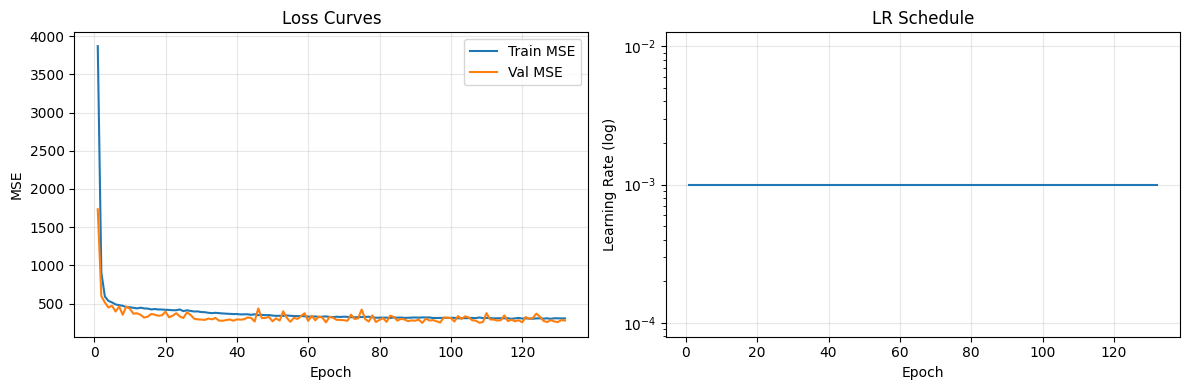

In [87]:
# ============================================================
# CELL 15 — Training Loop
# ============================================================
 
def run_epoch(loader, model, criterion, optimizer, device, training: bool) -> float:
    model.train() if training else model.eval()
    total_loss = 0.0
    n_samples  = 0

    with torch.set_grad_enabled(training):       # ← replaces the enable_grad() variable pattern
        for batch_idx, (X_batch, y_batch) in enumerate(loader):
            X_batch = X_batch.to(device)         # removed non_blocking — safe on CPU
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss  = criterion(preds, y_batch)

            # ── NaN guard: skip corrupt batch, warn once ──────
            if torch.isnan(loss) or torch.isinf(loss):
                if batch_idx == 0:               # only spam on first occurrence
                    print(f"\n  ⚠ NaN/Inf loss (batch {batch_idx}) "
                          f"X∈[{X_batch.min():.3f},{X_batch.max():.3f}] "
                          f"pred∈[{preds.min():.3f},{preds.max():.3f}] "
                          f"y∈[{y_batch.min():.3f},{y_batch.max():.3f}]")
                continue

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_batch)
            n_samples  += len(y_batch)

    if n_samples == 0:
        return float("nan")
    return total_loss / n_samples
 
 
# ── History containers ────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "lr": []}
 
print(f"Starting training — {EPOCHS} epochs max, early-stop patience={PATIENCE}")
print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  "
      f"{'Train RMSE':>11}  {'Val RMSE':>10}  {'LR':>9}  {'Time':>6}")
print("─" * 72)
 
t_start = time.time()
 
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
 
    train_loss = run_epoch(train_loader, model, criterion,
                           optimizer, DEVICE, training=True)
    val_loss   = run_epoch(val_loader,   model, criterion,
                           optimizer, DEVICE, training=False)
 
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
 
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)
 
    elapsed = time.time() - t0
 
    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  "
              f"{math.sqrt(train_loss):>11.4f}  {math.sqrt(val_loss):>10.4f}  "
              f"{current_lr:>9.2e}  {elapsed:>5.1f}s")
 
    if stopper.step(val_loss, model):
        print(f"\n⏹  Early stopping at epoch {epoch} "
              f"(best val MSE = {stopper.best_loss:.4f})")
        break
 
stopper.restore_best(model)
total_time = time.time() - t_start
print(f"\n✓  Training complete in {total_time/60:.1f} min")
print(f"   Best val MSE  : {stopper.best_loss:.4f}  "
      f"(RMSE = {math.sqrt(stopper.best_loss):.4f})")
 
 
# ── Training curve ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
epochs_ran = len(history["train_loss"])
x          = range(1, epochs_ran + 1)
 
ax1.plot(x, history["train_loss"], label="Train MSE")
ax1.plot(x, history["val_loss"],   label="Val MSE")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE")
ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(alpha=0.3)
 
ax2.semilogy(x, history["lr"])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate (log)")
ax2.set_title("LR Schedule"); ax2.grid(alpha=0.3)
 
plt.tight_layout(); plt.show()

In [88]:
# ============================================================
# CELL 16 — Evaluation on Test Set
# ============================================================
 
model.eval()
all_preds, all_true = [], []
 
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())
 
y_pred = np.array(all_preds)
y_true = np.array(all_true)
 
test_rmse  = rmse(y_pred, y_true)
test_score = cmapss_score(y_pred, y_true)
 
print(f"\n{'═'*45}")
print(f"  TEST RESULTS — {ACTIVE_SUBSET}")
print(f"{'═'*45}")
print(f"  RMSE  : {test_rmse:.4f}")
print(f"  Score : {test_score:.2f}  (lower is better)")
print(f"{'═'*45}")
 
# Paper's DCNN baseline on FD001: RMSE=12.61, Score=273.7
# A well-tuned Transformer should reach RMSE ~11-12, Score ~220-270
print(f"\n  Paper DCNN baseline (FD001): RMSE=12.61, Score=273.7")
delta = test_rmse - 12.61
print(f"  Your model vs. baseline    : RMSE {'+' if delta>0 else ''}{delta:.2f}")
 
 
# ── Per-engine error analysis ─────────────────────────────────
errors = y_pred - y_true
mae    = np.abs(errors).mean()
bias   = errors.mean()               # + = systematic over-prediction
 
print(f"\n  MAE  : {mae:.4f}")
print(f"  Bias : {bias:+.4f}  "
      f"({'over-predicting RUL (late — dangerous)' if bias > 0 else 'under-predicting RUL (early — conservative)'})")


═════════════════════════════════════════════
  TEST RESULTS — FD004
═════════════════════════════════════════════
  RMSE  : 19.6693
  Score : 6339.25  (lower is better)
═════════════════════════════════════════════

  Paper DCNN baseline (FD001): RMSE=12.61, Score=273.7
  Your model vs. baseline    : RMSE +7.06

  MAE  : 12.9076
  Bias : +0.7733  (over-predicting RUL (late — dangerous))


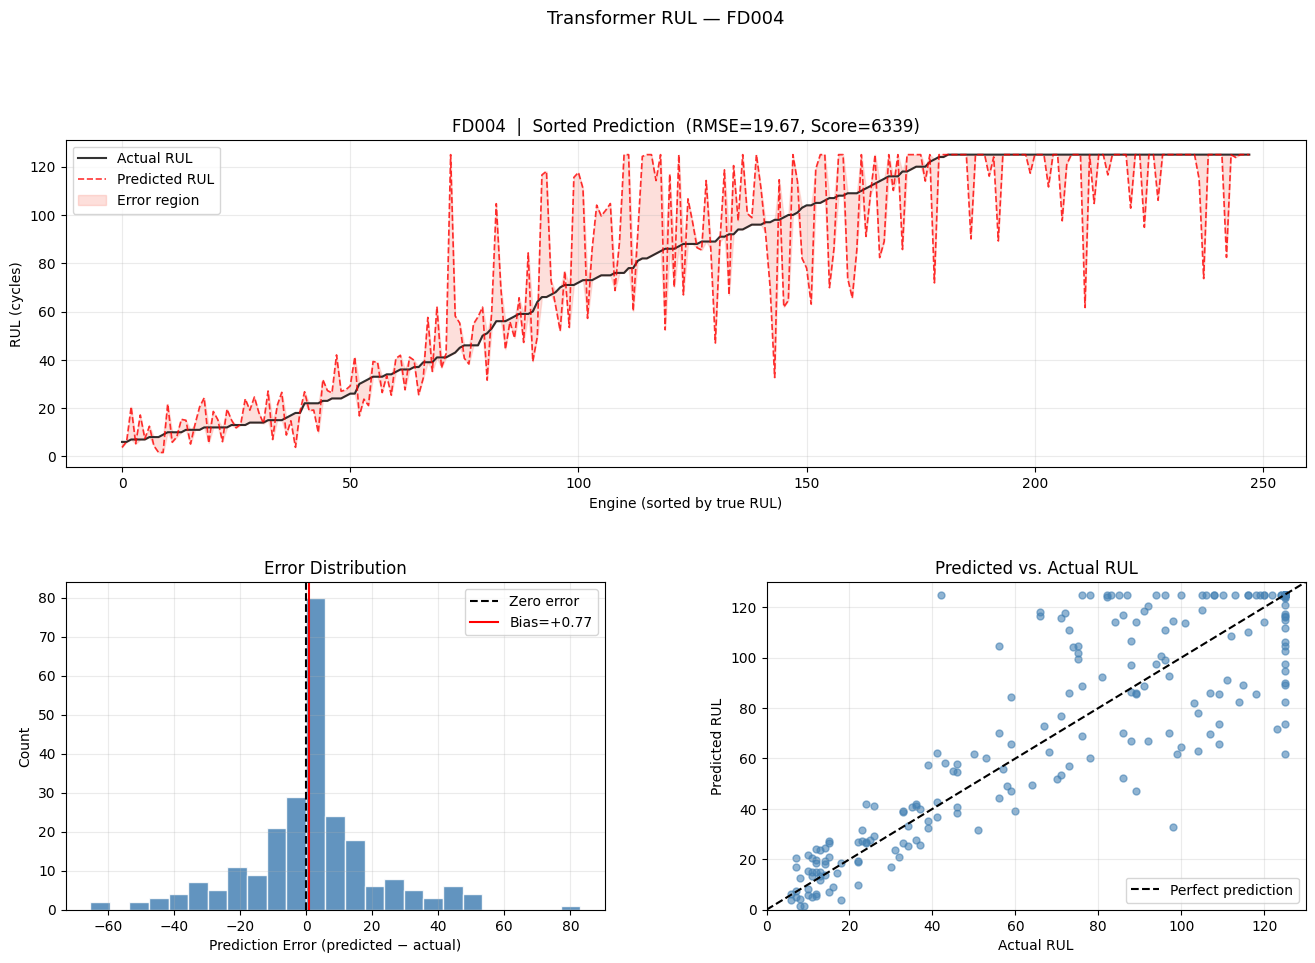

✓  Figure saved


In [89]:
# ============================================================
# CELL 17 — Visualisations
# ============================================================
 
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)
 
# ── Plot 1: Predicted vs Actual (sorted by true RUL) ─────────
ax1  = fig.add_subplot(gs[0, :])
idx  = np.argsort(y_true)
x_ax = np.arange(len(y_true))
 
ax1.plot(x_ax, y_true[idx],  "k-",  lw=1.5, label="Actual RUL",    alpha=0.8)
ax1.plot(x_ax, y_pred[idx],  "r--", lw=1.2, label="Predicted RUL", alpha=0.8)
ax1.fill_between(x_ax,
                 np.minimum(y_true[idx], y_pred[idx]),
                 np.maximum(y_true[idx], y_pred[idx]),
                 color="salmon", alpha=0.25, label="Error region")
 
ax1.set_xlabel("Engine (sorted by true RUL)")
ax1.set_ylabel("RUL (cycles)")
ax1.set_title(f"{ACTIVE_SUBSET}  |  Sorted Prediction  "
              f"(RMSE={test_rmse:.2f}, Score={test_score:.0f})")
ax1.legend(); ax1.grid(alpha=0.25)
 
# ── Plot 2: Error distribution ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(errors, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax2.axvline(0,    color="black", lw=1.5, ls="--", label="Zero error")
ax2.axvline(bias, color="red",   lw=1.5, ls="-",  label=f"Bias={bias:+.2f}")
ax2.set_xlabel("Prediction Error (predicted − actual)")
ax2.set_ylabel("Count")
ax2.set_title("Error Distribution")
ax2.legend(); ax2.grid(alpha=0.25)
 
# ── Plot 3: Scatter — predicted vs actual ────────────────────
ax3 = fig.add_subplot(gs[1, 1])
lims = [0, RUL_CEILING + 5]
ax3.scatter(y_true, y_pred, alpha=0.6, s=25, color="steelblue")
ax3.plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")
ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_xlabel("Actual RUL");  ax3.set_ylabel("Predicted RUL")
ax3.set_title("Predicted vs. Actual RUL")
ax3.legend(); ax3.grid(alpha=0.25)
 
plt.suptitle(f"Transformer RUL — {ACTIVE_SUBSET}", fontsize=13, y=1.01)
plt.savefig(f"results_{ACTIVE_SUBSET}.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Figure saved")

In [90]:
# ============================================================
# CELL 16b — Debug NaN test metrics
# ============================================================

import numpy as np

print('y_pred shape:', getattr(y_pred, 'shape', None), 'y_true shape:', getattr(y_true, 'shape', None))
print('y_pred nan/inf:', int(np.isnan(y_pred).sum()), '/', int(np.isinf(y_pred).sum()))
print('y_true nan/inf:', int(np.isnan(y_true).sum()), '/', int(np.isinf(y_true).sum()))

# Check one forward pass directly
model.eval()
with torch.no_grad():
    Xb, yb = next(iter(test_loader))
    pred_b = model(Xb.to(DEVICE)).detach().cpu().numpy()

print('one-batch X nan/inf:', int(np.isnan(Xb.numpy()).sum()), '/', int(np.isinf(Xb.numpy()).sum()))
print('one-batch y nan/inf:', int(np.isnan(yb.numpy()).sum()), '/', int(np.isinf(yb.numpy()).sum()))
print('one-batch pred nan/inf:', int(np.isnan(pred_b).sum()), '/', int(np.isinf(pred_b).sum()))
print('pred min/max:', np.nanmin(pred_b), np.nanmax(pred_b))


y_pred shape: (248,) y_true shape: (248,)
y_pred nan/inf: 0 / 0
y_true nan/inf: 0 / 0
one-batch X nan/inf: 0 / 0
one-batch y nan/inf: 0 / 0
one-batch pred nan/inf: 0 / 0
pred min/max: 1.6144602 125.0


In [91]:
# ============================================================
# CELL 18 — Save Model Checkpoint
# ============================================================
 
import joblib
from pathlib import Path
 
ckpt_dir = Path("checkpoints"); ckpt_dir.mkdir(exist_ok=True)
 
torch.save({
    "model_state_dict" : model.state_dict(),
    "model_config"     : {
        "n_features"     : len(FEATURE_COLS),
        "d_model"        : 64,
        "nhead"          : 8,
        "num_layers"     : 3,
        "dim_feedforward": 256,
        "dropout"        : 0.1,
        "fc_dim"         : 64,
        "rul_ceiling"    : float(RUL_CEILING),
    },
    "subset"           : ACTIVE_SUBSET,
    "seq_len"          : SEQ_LEN,
    "feature_cols"     : FEATURE_COLS,
    "test_rmse"        : test_rmse,
    "test_score"       : test_score,
    "history"          : history,
}, ckpt_dir / f"transformer_{ACTIVE_SUBSET}.pt")
 
print(f"✓  Checkpoint saved → checkpoints/transformer_{ACTIVE_SUBSET}.pt")
print(f"\n  To reload:")
print(f"  ckpt  = torch.load('checkpoints/transformer_{ACTIVE_SUBSET}.pt')")
print(f"  model = TransformerRUL(**ckpt['model_config']).to(DEVICE)")
print(f"  model.load_state_dict(ckpt['model_state_dict'])")

✓  Checkpoint saved → checkpoints/transformer_FD004.pt

  To reload:
  ckpt  = torch.load('checkpoints/transformer_FD004.pt')
  model = TransformerRUL(**ckpt['model_config']).to(DEVICE)
  model.load_state_dict(ckpt['model_state_dict'])


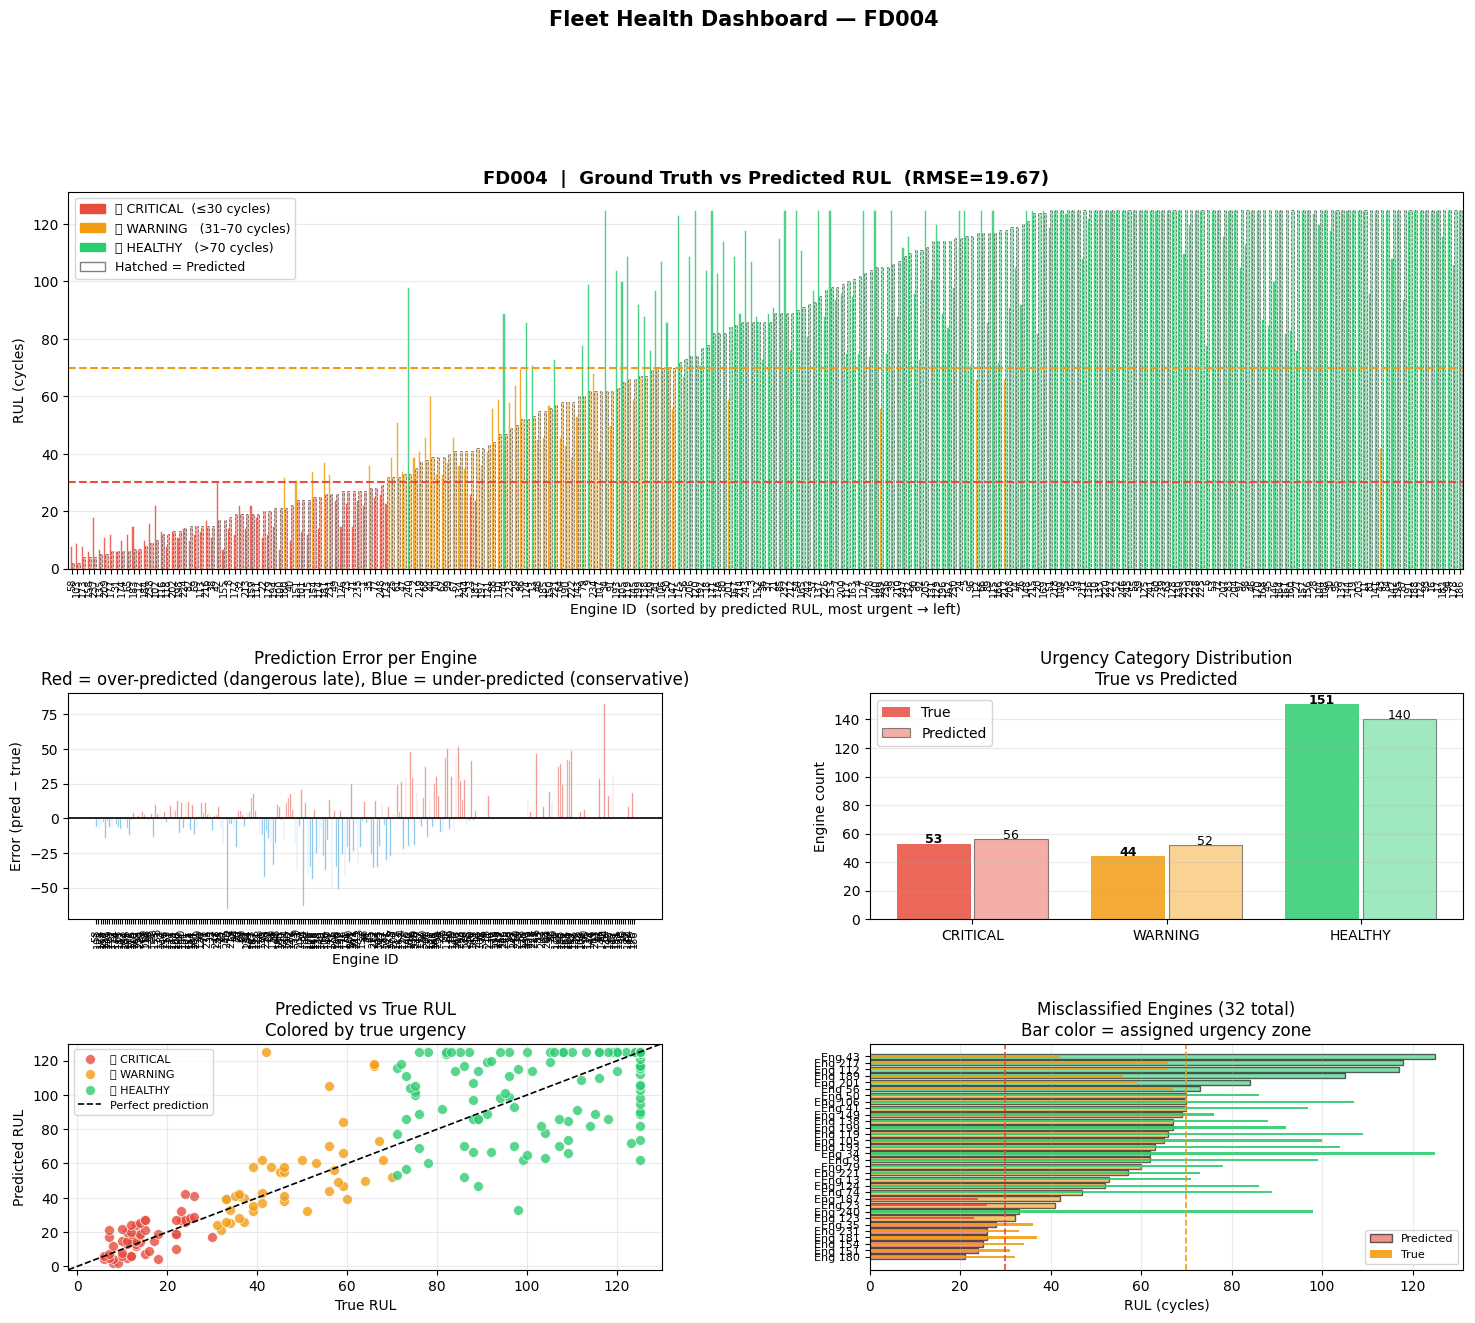


═════════════════════════════════════════════════════════════════
  FLEET TRIAGE REPORT — FD004  (sorted by predicted RUL, most urgent first)
═════════════════════════════════════════════════════════════════
    Engine   True RUL   Pred RUL    Error  True Status     Pred Status
  ────────  ─────────  ─────────  ───────  ──────────────  ──────────────
        58          8          2     -6.4  🔴 CRITICAL      🔴 CRITICAL
       103          9          2     -7.4  🔴 CRITICAL      🔴 CRITICAL
       173          8          4     -3.7  🔴 CRITICAL      🔴 CRITICAL
       158          6          4     -2.3  🔴 CRITICAL      🔴 CRITICAL
       237         18          4    -14.2  🔴 CRITICAL      🔴 CRITICAL
       135          7          5     -1.8  🔴 CRITICAL      🔴 CRITICAL
       209         11          5     -5.9  🔴 CRITICAL      🔴 CRITICAL
       177         12          6     -6.4  🔴 CRITICAL      🔴 CRITICAL
        31          6          6     +0.1  🔴 CRITICAL      🔴 CRITICAL
       174      

In [92]:
from matplotlib.patches import Patch
# ── Urgency thresholds (cycles) ───────────────────────────────
CRITICAL_THRESHOLD  = 30   # needs immediate shutdown/maintenance
WARNING_THRESHOLD   = 70   # schedule maintenance soon
HEALTHY_THRESHOLD   = 70   # above this = safe to delay

def classify_urgency(rul):
    if rul <= CRITICAL_THRESHOLD:
        return "🔴 CRITICAL"
    elif rul <= WARNING_THRESHOLD:
        return "🟡 WARNING"
    else:
        return "🟢 HEALTHY"

# ── Build comparison DataFrame ────────────────────────────────
unit_ids = sorted(test_raw["unit"].unique())

triage_df = pd.DataFrame({
    "engine_id"    : unit_ids,
    "true_RUL"     : y_true.astype(int),
    "pred_RUL"     : np.clip(np.round(y_pred).astype(int), 0, RUL_CEILING),
    "error"        : np.round(y_pred - y_true, 1),
})

triage_df["true_status"] = triage_df["true_RUL"].apply(classify_urgency)
triage_df["pred_status"] = triage_df["pred_RUL"].apply(classify_urgency)
triage_df["status_match"] = triage_df["true_status"] == triage_df["pred_status"]

# Sort by predicted RUL ascending (most urgent first)
triage_df = triage_df.sort_values("pred_RUL").reset_index(drop=True)

# ── Color maps ────────────────────────────────────────────────
STATUS_COLOR = {
    "🔴 CRITICAL" : "#e74c3c",
    "🟡 WARNING"  : "#f39c12",
    "🟢 HEALTHY"  : "#2ecc71",
}

def bar_color(status):
    return STATUS_COLOR[status]

# ── Figure layout ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.35,
                        height_ratios=[2, 1.2, 1.2])

engines = np.arange(len(triage_df))

# ── Plot 1: Side-by-side bar — True vs Predicted RUL ─────────
ax1 = fig.add_subplot(gs[0, :])
bar_w = 0.38
bars_true = ax1.bar(engines - bar_w/2, triage_df["true_RUL"],
                    width=bar_w, label="Ground Truth RUL",
                    color=[bar_color(s) for s in triage_df["true_status"]],
                    alpha=0.85, edgecolor="white", linewidth=0.5)
bars_pred = ax1.bar(engines + bar_w/2, triage_df["pred_RUL"],
                    width=bar_w, label="Predicted RUL",
                    color=[bar_color(s) for s in triage_df["pred_status"]],
                    alpha=0.5, edgecolor="black", linewidth=0.6, linestyle="--")

ax1.axhline(CRITICAL_THRESHOLD, color="#e74c3c", lw=1.5, ls="--",
            label=f"Critical threshold ({CRITICAL_THRESHOLD} cycles)")
ax1.axhline(WARNING_THRESHOLD,  color="#f39c12", lw=1.5, ls="--",
            label=f"Warning threshold  ({WARNING_THRESHOLD} cycles)")

ax1.set_xticks(engines)
ax1.set_xticklabels(triage_df["engine_id"], fontsize=7, rotation=90)
ax1.set_xlabel("Engine ID  (sorted by predicted RUL, most urgent → left)")
ax1.set_ylabel("RUL (cycles)")
ax1.set_title(f"{ACTIVE_SUBSET}  |  Ground Truth vs Predicted RUL  "
              f"(RMSE={test_rmse:.2f})", fontsize=13, fontweight="bold")

legend_patches = [
    Patch(color="#e74c3c", label="🔴 CRITICAL  (≤30 cycles)"),
    Patch(color="#f39c12", label="🟡 WARNING   (31–70 cycles)"),
    Patch(color="#2ecc71", label="🟢 HEALTHY   (>70 cycles)"),
    Patch(facecolor="white", edgecolor="black", alpha=0.5,
          label="Hatched = Predicted"),
]
ax1.legend(handles=legend_patches, loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.25)
ax1.set_xlim(-0.6, len(engines) - 0.4)

# ── Plot 2: Prediction error per engine ───────────────────────
ax2 = fig.add_subplot(gs[1, 0])
colors_err = ["#e74c3c" if e > 0 else "#3498db" for e in triage_df["error"]]
ax2.bar(engines, triage_df["error"], color=colors_err, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="black", lw=1.2)
ax2.set_xticks(engines)
ax2.set_xticklabels(triage_df["engine_id"], fontsize=7, rotation=90)
ax2.set_xlabel("Engine ID"); ax2.set_ylabel("Error (pred − true)")
ax2.set_title("Prediction Error per Engine\n"
              "Red = over-predicted (dangerous late), Blue = under-predicted (conservative)")
ax2.grid(axis="y", alpha=0.25)

# ── Plot 3: Urgency category counts ───────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
categories   = ["🔴 CRITICAL", "🟡 WARNING", "🟢 HEALTHY"]
true_counts  = [( triage_df["true_status"] == c).sum() for c in categories]
pred_counts  = [( triage_df["pred_status"] == c).sum() for c in categories]
cat_colors   = ["#e74c3c", "#f39c12", "#2ecc71"]
x = np.arange(len(categories))
ax3.bar(x - 0.2, true_counts, 0.38, label="True",      color=cat_colors, alpha=0.85)
ax3.bar(x + 0.2, pred_counts, 0.38, label="Predicted", color=cat_colors, alpha=0.45,
        edgecolor="black", linewidth=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(["CRITICAL", "WARNING", "HEALTHY"])
ax3.set_ylabel("Engine count")
ax3.set_title("Urgency Category Distribution\nTrue vs Predicted")
ax3.legend(); ax3.grid(axis="y", alpha=0.25)
for i, (tc, pc) in enumerate(zip(true_counts, pred_counts)):
    ax3.text(i - 0.2, tc + 0.3, str(tc), ha="center", fontsize=9, fontweight="bold")
    ax3.text(i + 0.2, pc + 0.3, str(pc), ha="center", fontsize=9)

# ── Plot 4: Scatter true vs pred colored by urgency ───────────
ax4 = fig.add_subplot(gs[2, 0])
for status, col in STATUS_COLOR.items():
    mask = triage_df["true_status"] == status
    ax4.scatter(triage_df.loc[mask, "true_RUL"],
                triage_df.loc[mask, "pred_RUL"],
                c=col, label=status, alpha=0.8, s=50, edgecolors="white", lw=0.5)
lims = [-2, RUL_CEILING + 5]
ax4.plot(lims, lims, "k--", lw=1.2, label="Perfect prediction")
ax4.set_xlim(lims); ax4.set_ylim(lims)
ax4.set_xlabel("True RUL"); ax4.set_ylabel("Predicted RUL")
ax4.set_title("Predicted vs True RUL\nColored by true urgency")
ax4.legend(fontsize=8); ax4.grid(alpha=0.25)

# ── Plot 5: Misclassified urgency ─────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
misclassified = triage_df[~triage_df["status_match"]].copy()
if len(misclassified) == 0:
    ax5.text(0.5, 0.5, "✅ All engines correctly\ntriaged by model",
             ha="center", va="center", fontsize=14, color="green",
             transform=ax5.transAxes)
    ax5.set_title("Urgency Misclassifications")
else:
    mc_colors = [bar_color(s) for s in misclassified["pred_status"]]
    ax5.barh(range(len(misclassified)), misclassified["pred_RUL"],
             color=mc_colors, alpha=0.6, label="Predicted", edgecolor="black")
    ax5.barh(range(len(misclassified)), misclassified["true_RUL"],
             color=[bar_color(s) for s in misclassified["true_status"]],
             alpha=0.9, label="True", height=0.35)
    ax5.set_yticks(range(len(misclassified)))
    ax5.set_yticklabels([f"Eng {eid}" for eid in misclassified["engine_id"]], fontsize=8)
    ax5.set_xlabel("RUL (cycles)")
    ax5.set_title(f"Misclassified Engines ({len(misclassified)} total)\n"
                  "Bar color = assigned urgency zone")
    ax5.axvline(CRITICAL_THRESHOLD, color="#e74c3c", lw=1.2, ls="--")
    ax5.axvline(WARNING_THRESHOLD,  color="#f39c12", lw=1.2, ls="--")
    ax5.legend(fontsize=8); ax5.grid(axis="x", alpha=0.25)

plt.suptitle(f"Fleet Health Dashboard — {ACTIVE_SUBSET}", fontsize=15,
             fontweight="bold", y=1.01)
plt.savefig(f"triage_{ACTIVE_SUBSET}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Printed triage report ─────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  FLEET TRIAGE REPORT — {ACTIVE_SUBSET}  "
      f"(sorted by predicted RUL, most urgent first)")
print(f"{'═'*65}")
print(f"  {'Engine':>8}  {'True RUL':>9}  {'Pred RUL':>9}  "
      f"{'Error':>7}  {'True Status':<14}  Pred Status")
print(f"  {'─'*8}  {'─'*9}  {'─'*9}  {'─'*7}  {'─'*14}  {'─'*14}")

for _, row in triage_df.iterrows():
    flag = "  ⚠ MISMATCH" if not row["status_match"] else ""
    print(f"  {int(row['engine_id']):>8}  {int(row['true_RUL']):>9}  "
          f"{int(row['pred_RUL']):>9}  {row['error']:>+7.1f}  "
          f"{row['true_status']:<14}  {row['pred_status']}{flag}")

print(f"\n{'─'*65}")
print(f"  SUMMARY")
print(f"{'─'*65}")
for cat, col in zip(categories, cat_colors):
    tc = (triage_df["true_status"] == cat).sum()
    pc = (triage_df["pred_status"] == cat).sum()
    label = cat.split()[-1]
    print(f"  {cat}  →  True: {tc:>3}  |  Predicted: {pc:>3}")

n_mis = (~triage_df["status_match"]).sum()
n_dangerous = ((triage_df["true_status"] == "🔴 CRITICAL") &
               (triage_df["pred_status"] != "🔴 CRITICAL")).sum()
print(f"\n  Total misclassified        : {n_mis} / {len(triage_df)}")
print(f"  ⚠  Dangerous misses (Critical predicted as non-Critical): {n_dangerous}")
print(f"{'═'*65}")
print(f"\n  ACTION ITEMS:")
critical_engines = triage_df[triage_df["pred_status"] == "🔴 CRITICAL"]["engine_id"].tolist()
warning_engines  = triage_df[triage_df["pred_status"] == "🟡 WARNING"]["engine_id"].tolist()
healthy_engines  = triage_df[triage_df["pred_status"] == "🟢 HEALTHY"]["engine_id"].tolist()
print(f"  🔴 SHUT DOWN / IMMEDIATE MAINTENANCE  : engines {critical_engines}")
print(f"  🟡 SCHEDULE MAINTENANCE (next window) : engines {warning_engines}")
print(f"  🟢 SAFE TO CONTINUE OPERATING         : engines {healthy_engines}")